In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.colors as mcolors
import colorsys

In [2]:
# define what is what color
plotColors = plt.rcParams['axes.prop_cycle'].by_key()['color']
typeColor = {
    "BH" :              plotColors[0],
    "MM" :              plotColors[1],
    "rBH" :             plotColors[2],
    "rMM" :             plotColors[3],
    "PM" :              plotColors[4],
    "FMM" :             plotColors[5],
    "SYM FMM" :         plotColors[6],
    "varying BH" :      plotColors[7],
    "varying FMM" :     plotColors[8],
    "varying SYM FMM" : plotColors[9],
}

In [101]:
# define what is what color
plotColors = plt.rcParams['axes.prop_cycle'].by_key()['color']
base_rgb = mcolors.to_rgb(plotColors[6])

def adjust_saturation(rgb, saturation_scale):
    # Convert RGB [0,1] to HLS
    h, l, s = colorsys.rgb_to_hls(*rgb)
    # Apply scale to saturation (clamping between 0 and 1)
    new_s = max(0, min(1, s * saturation_scale))
    # Convert back to RGB then to Hex for Matplotlib
    return mcolors.to_hex(colorsys.hls_to_rgb(h, l, new_s))

typeColor = {
    "1" :  adjust_saturation(base_rgb, 6.0/6.0),
    "2" :  adjust_saturation(base_rgb, 5.0/6.0),
    "4" :  adjust_saturation(base_rgb, 4.0/6.0),
    "8" :  adjust_saturation(base_rgb, 3.0/6.0),
    "16" : adjust_saturation(base_rgb, 2.0/6.0),
    "32" : adjust_saturation(base_rgb, 1.0/6.0),
    "64" : adjust_saturation(base_rgb, 0.0/6.0),
}

In [3]:
def plotGraph(locationLabels, 
              begin, end, 
              xName, yName, 
              plotSaveName, 
              flip=False, 
              xMin=None, xMax=None, yMin=None, yMax=None, 
              horizontal=None, vertical=None, 
              showTheta=True, 
              styles=None,
              showOnlyThisTheta=None):



    
    
    plt.figure()



    if styles is None:
        styles = {} # Start with an empty dict
    
    # convert dictionary to list
    files = list(locationLabels.keys())
    labels = list(locationLabels.values())

    for i in range(len(files)):
        file = files[i]
        label = labels[i]
        color = typeColor[label]

        s = styles.get(label, {"ls": "-", "marker": None, "lw": 1.5, "z": 2})

        data = pd.read_csv(file, header=None)
        if flip:
            x = data[1][begin:end].reset_index(drop=True)
            y = data[0][begin:end].reset_index(drop=True)
        else:
            x = data[0][begin:end].reset_index(drop=True)
            y = data[1][begin:end].reset_index(drop=True)

        if data.shape[1] >= 3 and showTheta:
            if showOnlyThisTheta is None:
                plt.plot(x, y, label=label, marker='o', color=color,
                     linestyle=s["ls"], 
                     #marker=s["marker"], 
                     linewidth=s["lw"], 
                     zorder=s["z"],
                     markersize=6)
                annotations = data[2][begin:end].reset_index(drop=True)
                for i in range(len(x)):
                    plt.text(x[i], y[i], f"{annotations[i]:.2f}", fontsize=8, ha='right', va='bottom', clip_on=True)
            else:
                if label == showOnlyThisTheta:
                    plt.plot(x, y, label=label, marker='o', color=color,
                             linestyle=s["ls"], 
                             linewidth=s["lw"], 
                             zorder=s["z"],
                             markersize=6)
                    annotations = data[2][begin:end].reset_index(drop=True)
                    for i in range(len(x)):
                        plt.text(x[i], y[i], f"{annotations[i]:.2f}", fontsize=8, ha='right', va='bottom', clip_on=True)
                else:
                    # Otherwise, just plot the line normally
                    plt.plot(x, y, label=label, color=color,
                             linestyle=s["ls"], 
                             marker=s["marker"], 
                             linewidth=s["lw"], 
                             zorder=s["z"],
                             markersize=6)
        else:
            plt.plot(x, y, label=label, color=color,
                 linestyle=s["ls"], 
                 marker=s["marker"], 
                 linewidth=s["lw"], 
                 zorder=s["z"],
                 markersize=6)
            annotations = ["" for _ in range(len(x))]
        
    if flip:
        plt.xlabel(yName)
        plt.ylabel(xName)
    else:
        plt.xlabel(xName)
        plt.ylabel(yName)
    
    
    if xMin is not None and xMax is not None:
        plt.xlim(xMin, xMax)
    if yMin is not None and yMax is not None:
        plt.ylim(yMin, yMax)
    #plt.yscale('log') # makes y axis logarithmic

    ax = plt.gca()
    
    if horizontal is not None:
        plt.axhline(y=horizontal, color='red', linestyle='--')#, label=f'Allowable Error = {allowableError}')
        #ymin, ymax = ax.get_ylim()
        #ax.axhspan(ymin, horizontal, color='red', alpha=0.15, zorder=0)
    if vertical is not None:
        plt.axvline(x=vertical, color='blue', linestyle='--')#, label=f'Allowable Error = {allowableError}')
        xmin, xmax = ax.get_xlim()
        ax.axvspan(xmin, vertical, color='blue', alpha=0.15, zorder=0)
    
    plt.legend()
    plt.savefig(plotSaveName, dpi=300)
    plt.show()
    
    

def plotBar(locationLabels, xName, yName, plotSaveName):
    plt.figure()
    
    # convert dictionary to list
    files = list(locationLabels.keys())
    labels = list(locationLabels.values())
    
    means = []
    std = []

    for i in range(len(files)):
        file = files[i]
        label = labels[i]
        #color = typeColor[label]

        data = pd.read_csv(file, header=None)
        values = data[1].astype(float)

        mean_i = values.mean()
        print(label, ", ", mean_i)
        means.append(mean_i)
        std.append(values.std())



    barAmount = np.arange(len(means))

    plt.bar(barAmount, means, yerr=std, capsize=8)
    plt.xticks(barAmount, labels)
    plt.title("Average Time per Method")
    plt.xlabel(xName)
    plt.ylabel(yName)
    plt.title("Bar Plot with Standard Deviation")
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.savefig(plotSaveName, dpi=300)
    plt.show()
    
    
    
def findTime(csvPath, target=1.0):
    df = pd.read_csv(csvPath, header=None, names=['x', 'y', 'z'])
    
    # Search for two z values that straddle the target
    for i in range(len(df) - 1):
        z1 = df.loc[i, 'z']
        z2 = df.loc[i+1, 'z']
        
        if z1 == target:
            return df.loc[i, 'x']
        if z2 == target:
            return df.loc[i+1, 'x']
        
        if z1 <= target <= z2:# or z2 <= target <= z1:
            # Linear interpolation for y
            x1 = df.loc[i, 'x']
            x2 = df.loc[i+1, 'x']

            # Interpolate y at target z
            xInterp = x1 + (target - z1) * (x2 - x1) / (z2 - z1)

            #print(f"Interpolated y at z={target}: {y_interp:.6f}")
            return xInterp

    #print(f"No two z-values found surrounding {targe"t}")
    return None

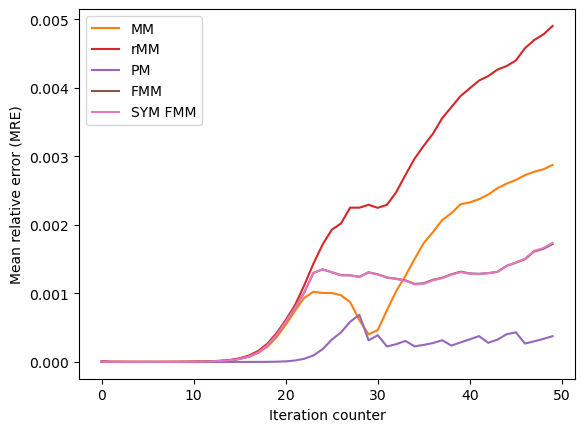

In [11]:
pointAmount = "10000"
theta = "0.5"
dataSet = "MNIST_digits"
perp = "30"

custom_labels = {
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBH_point"             + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "BH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHMP_point"           + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "MM",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHR_point"            + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "rBH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHRMP_point"          + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "rMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepPM_point"             + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "PM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepFMM_MORTON_point"     + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "FMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepFMM_SYM_MORTON_point" + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "SYM FMM",
}

plotGraph(custom_labels, 0, 1000, "Iteration counter", "Mean relative error (MRE)", "plotOutput/lines_plot.png", False, None, None, None, None)
x_range = 1000
y_range = 0.012
#plotGraph(custom_labels, 0, x_range, "Iteration counter", "Mean relative error (MRE)", "plotOutput/lines_plot.png", False, 0.0, x_range-1, 0.0, y_range)

BH ,  0.02419028028384
MM ,  0.011082502135988
rBH ,  0.4766231516
rMM ,  0.021859695413866
PM ,  0.0002902688732055529
FMM ,  0.008246232418824998
SYM FMM ,  0.00802154764036


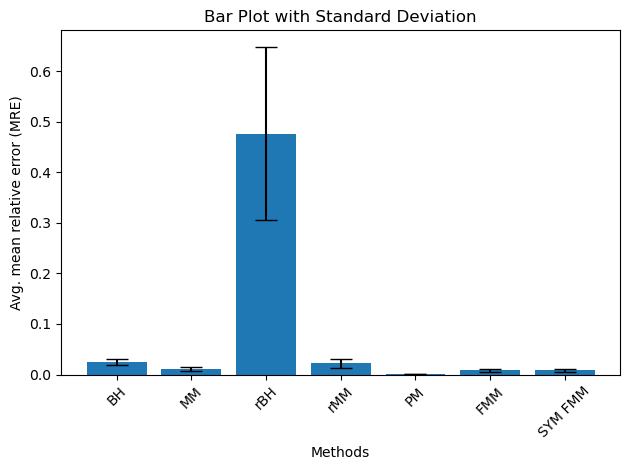

In [25]:
pointAmount = "70000"
theta = "0.5"
dataSet = "MNIST_digits"
perp = "30"

custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBH_point"             + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "BH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHMP_point"           + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "MM",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHR_point"            + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "rBH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHRMP_point"          + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "rMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepPM_point"             + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "PM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepFMM_MORTON_point"     + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "FMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepFMM_SYM_MORTON_point" + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "SYM FMM",
}

plotBar(custom_labels, "Methods", "Avg. mean relative error (MRE)", "plotOutput/lines_plot.png")

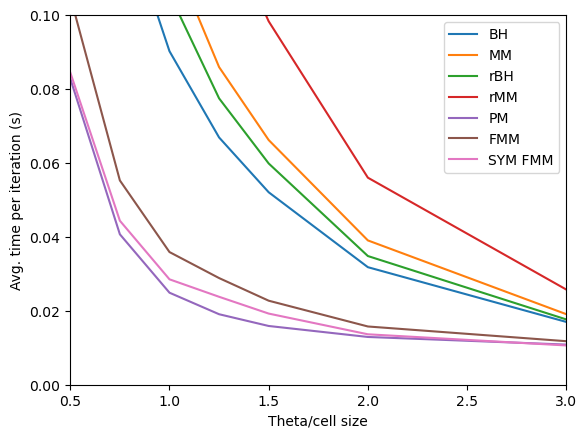

In [33]:
pointAmount = "70000"
dataSet = "MNIST_digits"
perp = "30"

custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaBH_point"    + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaBHMP_point"  + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "MM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaBHR_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "rBH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaBHRMP_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "rMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaPM_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "PM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaFMM_MORTON_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "FMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaFMM_SYM_MORTON_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "SYM FMM",
}

#plotGraph(custom_labels, 0, 1000, "Theta/cell size", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", False, None, None, None, None)
plotGraph(custom_labels, 0, 1000, "Theta/cell size", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", False, 0.5, 3.0, 0.0, 0.1, None, None)
#plotGraph(custom_labels, 0, 1000, "Theta/cell size", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", False, 0.5, 2.0, 0.0, 0.1, None, None)

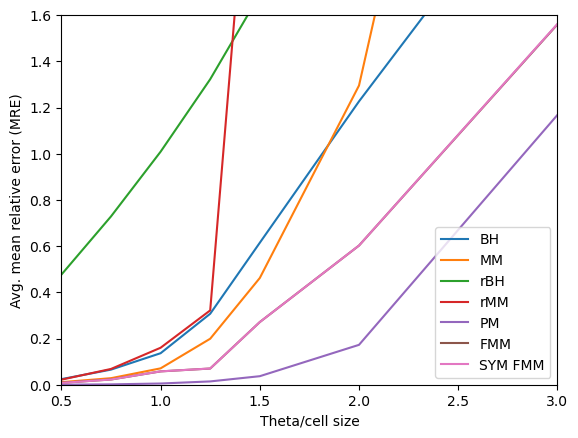

In [37]:
pointAmount = "70000"
dataSet = "MNIST_digits"
perp = "30"

custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaBH_point"    + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaBHMP_point"  + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "MM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaBHR_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "rBH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaBHRMP_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "rMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaPM_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "PM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaFMM_MORTON_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "FMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaFMM_SYM_MORTON_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "SYM FMM",
}

#plotGraph(custom_labels, 0, 1000, "Theta/cell size", "Avg. mean relative error (MRE)", "plotOutput/lines_plot.png")
plotGraph(custom_labels, 0, 1000, "Theta/cell size", "Avg. mean relative error (MRE)", "plotOutput/lines_plot.png", False, 0.5, 3.0, 0.0, 1.6, None, None)

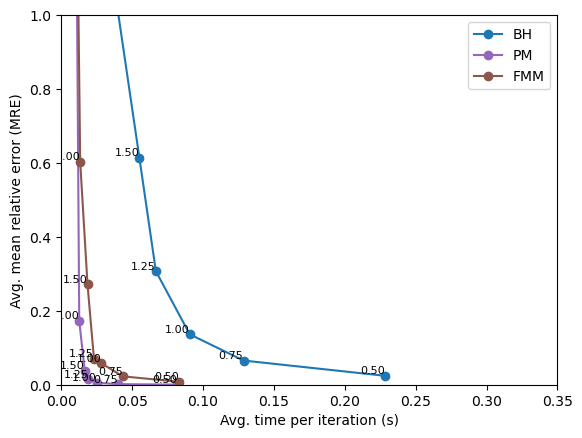

In [49]:
pointAmount = "70000"
dataSet = "MNIST_digits"
perp = "30"

#allowableError = findTime(os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorBH_point"    + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"), 0.5)

allowableError = 0.0241903
#allowableError = None

style_to_give = {
        "BH":  {"ls": "-",  "marker": "o", "lw": 1.5, "z": 2}, # Square
        "MM":  {"ls": "-",  "marker": "o", "lw": 1.5, "z": 2},  # Circle
        "rBH":  {"ls": "-",  "marker": "o", "lw": 1.5, "z": 2}, # Triangle
        "rMM":  {"ls": "-",  "marker": "o", "lw": 1.5, "z": 2},  # Down Triangle
        "PM": {"ls": "-",  "marker": "o", "lw": 1.5, "z": 2},  # X
        "FMM": {"ls": "-",  "marker": "o", "lw": 1.5, "z": 2},  # Plus
        "varying SYM FMM": {"ls": "-",  "marker": "o", "lw": 1.5, "z": 2}, # Dot
    }


custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorBH_point"      + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BH",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorBHMP_point"    + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "MM",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorBHR_point"     + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "rBH",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorBHRMP_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "rMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorPM_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "PM",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorFMM_MORTON_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "varying FMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorFMM_SYM_MORTON_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "FMM",
}

#plotGraph(custom_labels, 0, 1000, "Avg. mean relative error (MRE)", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, None, None, None, None, None, None, True)
#plotGraph(custom_labels, 0, 1000, "Avg. mean relative error (MRE)", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, 0.0, 0.11, 0.0, 0.2, allowableError, None, True)

plotGraph(custom_labels, 0, 1000, "Avg. mean relative error (MRE)", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, 0.0, 0.35, 0.0, 1.0, None, None, True, style_to_give)
#plotGraph(custom_labels, 0, 1000, "Avg. mean relative error (MRE)", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, 0.0, 0.11, 0.0, 0.2, None, None, True, style_to_give)
#plotGraph(custom_labels, 0, 1000, "Avg. mean relative error (MRE)", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, 0.0, 0.08, 0.0, 1.6, None, None, True)

#plotGraph(custom_labels, 0, 1000, "Avg. mean relative error (MRE)", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, 0.0, 0.25, 0.0, 1.0, None, None, True, style_to_give)

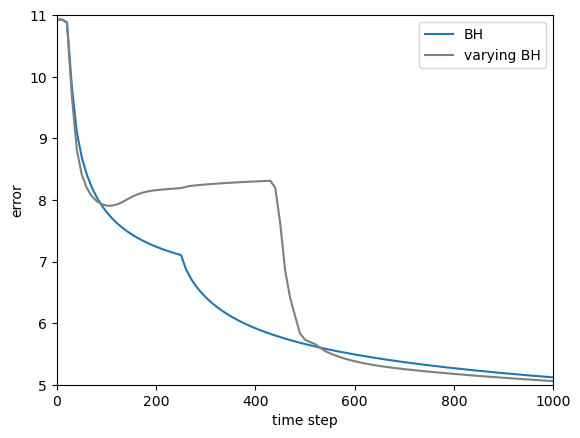

In [92]:
pointAmount = "70000"
min_theta = "0.75"
max_theta = "0.75"
max_theta_new = "3"
dataSet = "MNIST_digits"
perp = "30"

custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "costTimestepBH_point"             + pointAmount + "_perp" + perp + "_minTheta" + "0.5" + "_maxTheta" + "0.5"     + "_dataset" + dataSet + ".csv"): "BH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "costTimestepBH_point"             + pointAmount + "_perp" + perp + "_minTheta" + "0.5" + "_maxTheta" + "3" + "_dataset" + dataSet + ".csv"): "varying BH",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "costTimestepPM_point"             + pointAmount + "_perp" + perp + "_minTheta" + min_theta + "_maxTheta" + max_theta_new + "_dataset" + dataSet + ".csv"): "PM",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "costTimestepFMM_MORTON_point"     + pointAmount + "_perp" + perp + "_minTheta" + min_theta + "_maxTheta" + max_theta     + "_dataset" + dataSet + ".csv"): "FMM",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "costTimestepFMM_MORTON_point"     + pointAmount + "_perp" + perp + "_minTheta" + min_theta + "_maxTheta" + max_theta_new + "_dataset" + dataSet + ".csv"): "varying FMM",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "costTimestepFMM_SYM_MORTON_point" + pointAmount + "_perp" + perp + "_minTheta" + min_theta + "_maxTheta" + max_theta     + "_dataset" + dataSet + ".csv"): "SYM FMM",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "costTimestepFMM_SYM_MORTON_point" + pointAmount + "_perp" + perp + "_minTheta" + min_theta + "_maxTheta" + max_theta_new + "_dataset" + dataSet + ".csv"): "varying SYM FMM",
}

#plotGraph(custom_labels, 0, 1000, "Iteration counter", "Cost of the embedding", "plotOutput/lines_plot.png", False, None, None, None, None)

plotGraph(custom_labels, 0, 1000,"time step", "error", "plotOutput/lines_plot.png", False, 0.0, 1000.0, 5.0, 11.0)
#plotGraph(custom_labels, 0, 1000,"time step", "error", "plotOutput/lines_plot.png", False, 990.0, 1000.0, 5.1, 5.13)

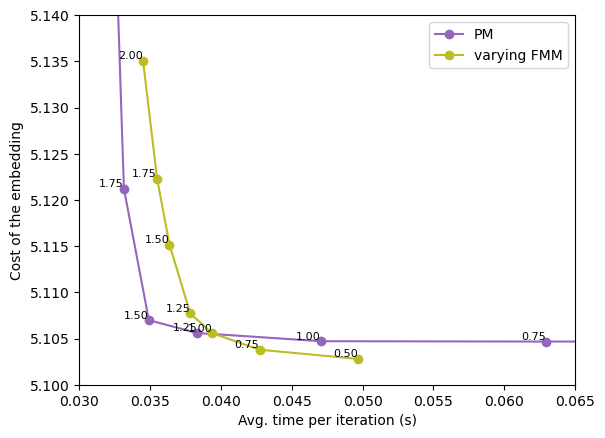

In [34]:
pointAmount = "70000"
dataSet = "MNIST_digits"
perp = "30"


custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeCostPM_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "PM",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeCostBH_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "varying BH",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeCostFMM_MORTON_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "varying FMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeCostFMM_SYM_MORTON_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "varying FMM",
}

#plotGraph(custom_labels, 0, 1000, "Cost of the embedding", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, None, None, None, None, None, None, True)

#plotGraph(custom_labels, 0, 1000, "Cost of the embedding", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, 0.028, 0.095, 5.025, 5.175, None, None, True, None)
plotGraph(custom_labels, 0, 1000, "Cost of the embedding", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, 0.03, 0.065, 5.1, 5.14, None, None, True)

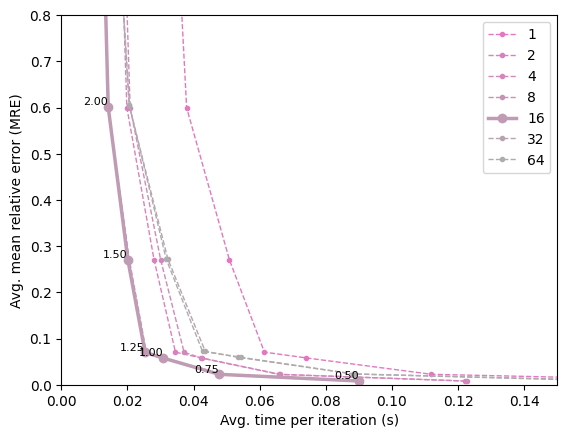

In [105]:
pointAmount = "70000"
dataSet = "MNIST_digits"
perp = "30"

method = "FMM_SYM_MORTON"

style_to_give = {
        "1":  {"ls": "--", "marker": ".", "lw": 1.0, "z": 1}, # Square
        "2":  {"ls": "--", "marker": ".", "lw": 1.0, "z": 1},  # Circle
        "4":  {"ls": "--", "marker": ".", "lw": 1.0, "z": 1},  # Triangle
        "8":  {"ls": "--", "marker": ".", "lw": 1.0, "z": 1},  # Down Triangle
        "16": {"ls": "-",  "marker": "o", "lw": 2.5, "z": 2},  # X
        "32": {"ls": "--", "marker": ".", "lw": 1.0, "z": 1},  # Plus
        "64": {"ls": "--", "marker": ".", "lw": 1.0, "z": 1},  # Dot
    }

custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorMAXPOINTS_" + str(1)  + method + "_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "1",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorMAXPOINTS_" + str(2)  + method + "_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "2",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorMAXPOINTS_" + str(4)  + method + "_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "4",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorMAXPOINTS_" + str(8)  + method + "_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "8",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorMAXPOINTS_" + str(16) + method + "_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "16",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorMAXPOINTS_" + str(32) + method + "_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "32",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorMAXPOINTS_" + str(64) + method + "_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "64",
}

#plotGraph(custom_labels, 0, 1000, "Avg. mean relative error (MRE)", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, None, None, None, None, None, None, True, style_to_give)
#plotGraph(custom_labels, 0, 1000, "Avg. mean relative error (MRE)", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, None, None, None, None, None, None, True, style_to_give, "16")

#plotGraph(custom_labels, 0, 1000, "Avg. mean relative error (MRE)", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, 0.0, 0.5, 0.0, 1.5, None, None, True, style_to_give, "16")
#plotGraph(custom_labels, 0, 1000, "Avg. mean relative error (MRE)", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, 0.0, 0.2, 0.0, 1.5, None, None, True, style_to_give, "16")
plotGraph(custom_labels, 0, 1000, "Avg. mean relative error (MRE)", "Avg. time per iteration (s)", "plotOutput/lines_plot.png", True, 0.0, 0.15, 0.0, 0.8, None, None, True, style_to_give, "16") # SYM FMM


In [212]:
custom_labels = {
    os.path.join("graphCSV","gravityErrorTimestepBH_point1000_theta1.csv"): "BH",
    os.path.join("graphCSV","gravityErrorTimestepBHMP_point1000_theta1.csv"): "BHMP",
    os.path.join("graphCSV","gravityErrorTimestepBHR_point1000_theta1.csv"): "BHR",
    os.path.join("graphCSV","gravityErrorTimestepBHRMP_point1000_theta1.csv"): "BHRMP",
    os.path.join("graphCSV","gravityErrorTimestepFMM_point1000_theta1.csv"): "FMM",
}


plotGraph(custom_labels, 0, 1000, "time step", "error", "plotOutput/lines_plot.png")

In [ ]:
custom_labels = {
    os.path.join("graphCSV","gravityErrorTimestepCompareFMM_point500_theta1.csv"): "FMM",
    os.path.join("graphCSV","gravityErrorTimestepCompareFMMnaive_point500_theta1.csv"): "FMMnaive",
}

plotGraph(custom_labels, 0, 500, "time step", "error", "plotOutput/lines_plot.png")

In [ ]:
custom_labels = {
    os.path.join("graphCSV","gravityCalculationtimeThetaBH_point1000.csv"): "BH",
    os.path.join("graphCSV","gravityCalculationtimeThetaBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","gravityCalculationtimeThetaBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","gravityCalculationtimeThetaBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","gravityCalculationtimeThetaFMM_point1000.csv"): "FMM",
    os.path.join("graphCSV","gravityCalculationtimeThetaNaive_point1000.csv"): "naive",
}

plotGraph(custom_labels, 0, 10, "theta", "average computation time", "plotOutput/lines_plot.png")

In [ ]:
custom_labels = {
    os.path.join("graphCSV","gravityErrorThetaBH_point1000.csv"): "BH",
    os.path.join("graphCSV","gravityErrorThetaBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","gravityErrorThetaBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","gravityErrorThetaBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","gravityErrorThetaFMM_point1000.csv"): "FMM",
}

plotGraph(custom_labels, 0, 55,"theta", "average error", "plotOutput/lines_plot.png")

In [ ]:
allowableError = findTime(os.path.join("graphCSV","gravityCalculationtimeErrorBH_point1000.csv"))

custom_labels = {
    os.path.join("graphCSV","gravityCalculationtimeErrorBH_point1000.csv"): "BH",
    os.path.join("graphCSV","gravityCalculationtimeErrorBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","gravityCalculationtimeErrorBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","gravityCalculationtimeErrorBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","gravityCalculationtimeErrorFMM_point1000.csv"): "FMM",
}


plotGraph(custom_labels, 0, 40,"error", "average calculation time", "plotOutput/lines_plot.png", True, 0, 0.005, 0, 0.012, allowableError)

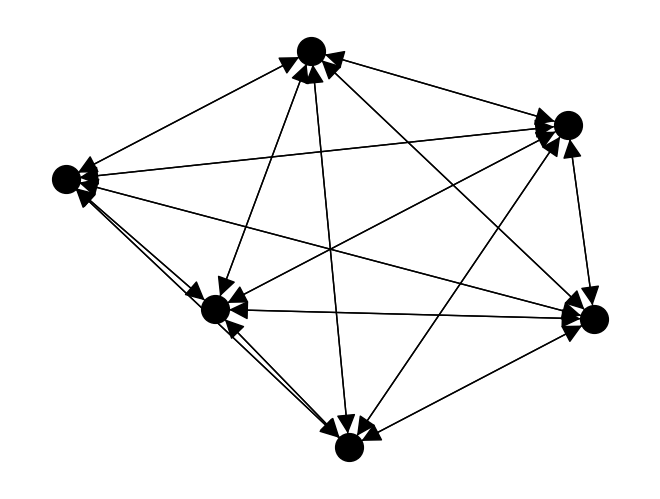

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add nodes
nodes = range(6)
G.add_nodes_from(nodes)

# Add directed edges between all distinct nodes
for i in nodes:
    for j in nodes:
        if i != j:
            G.add_edge(i, j)

# Draw the graph
pos = nx.spring_layout(G, seed=1)
nx.draw(
    G,
    pos,
    with_labels=False,
    node_color="black",
    node_size=400,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=30
)

plt.show()